In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carga de fuentes de datos
plans = pd.read_csv("./datasets/plans.csv")
users = pd.read_csv("./datasets/users_latam.csv")
usage = pd.read_csv("./datasets/usage.csv")

In [2]:
# Inspección de estructuras iniciales
plans.head()
users.head()
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [3]:
print("Dimensiones de plans:", plans.shape)
print("Dimensiones de users:", users.shape)
print("Dimensiones de usage:", usage.shape)

plans.info()
users.info()
usage.info()

Dimensiones de plans: (2, 8)
Dimensiones de users: (4000, 8)
Dimensiones de usage: (40000, 6)
<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      str    
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), str(1)
memory usage: 260.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     4000 non-null   int64
 1   first_name  4000 non-null   str  
 2   last_name   4000 n

In [4]:
# Evaluación de nulos en el perfil de usuarios
print("Valores absolutos:\n", users.isna().sum())
print("\nProporción relativa:\n", users.isna().mean())

Valores absolutos:
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción relativa:
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [5]:
# Evaluación de nulos en el registro de uso
print("Valores absolutos:\n", usage.isna().sum())
print("\nProporción relativa:\n", usage.isna().mean())

Valores absolutos:
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción relativa:
 id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


Diagnóstico Preliminar de Nulos:
users: La columna city presenta un 11% de valores ausentes que requieren evaluación. La columna churn_date tiene un 88% de nulos, lo cual es lógicamente correcto ya que representa a los clientes que se mantienen activos en la compañía.

usage: La columna date presenta una ausencia marginal (0.12%). Las columnas duration (55%) y length (44%) sugieren una estructura de datos faltantes condicionales al tipo de servicio.

In [6]:
# Auditoría de consistencia en variables de usuarios
print("Sentinels en user_id:", users["user_id"].isin([-999, 999]).sum())
print("Negativos en user_id:", users["user_id"].le(0).sum())
print("ID Duplicados:", users["user_id"].duplicated().sum())

print("-" * 40)

print("Sentinels en edad (-999):", users["age"].isin([-999, 999]).sum())
print("Edades negativas:", users["age"].le(0).sum())
print("Registros sobre el rango biológico (>=150 años):", users["age"].ge(150).sum())

Sentinels en user_id: 0
Negativos en user_id: 0
ID Duplicados: 0
----------------------------------------
Sentinels en edad (-999): 55
Edades negativas: 55
Registros sobre el rango biológico (>=150 años): 0


In [7]:
# Auditoría de consistencia en el registro transaccional de uso
print("Sentinels en ID de uso:", usage["id"].isin([-999, 999]).sum())
print("IDs de uso duplicados:", usage["id"].duplicated().sum())

print("-" * 40)

print("Sentinels en user_id (usage):", usage["user_id"].isin([-999, 999]).sum())
print("Usuarios únicos en transacciones:", usage["user_id"].nunique())

Sentinels en ID de uso: 1
IDs de uso duplicados: 0
----------------------------------------
Sentinels en user_id (usage): 0
Usuarios únicos en transacciones: 3999


In [8]:
# Auditoría de variables categóricas en usuarios
columnas_categoricas = ['city', 'plan']
print(users[columnas_categoricas].value_counts())
print("\nRegistros con caracteres de escape o incógnitas (?):")
print(users[columnas_categoricas].isin(["?", "NA", "UNKNOWN"]).sum())

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
Name: count, dtype: int64

Registros con caracteres de escape o incógnitas (?):
city    96
plan     0
dtype: int64


In [9]:
# Auditoría de variables categóricas en uso
print(usage['type'].value_counts())
print("Valores inválidos en tipo de uso:", usage['type'].isin(["?", "NA", "UNKNOWN"]).sum())

type
text    22092
call    17908
Name: count, dtype: int64
Valores inválidos en tipo de uso: 0


Diagnóstico de Sentinels e Inconsistencias:
La columna age posee un 1.3% de registros con el valor sentinel -999.

La columna city presenta un 2.4% de registros capturados con el carácter ?.

La tabla usage muestra una alta frecuencia de duplicados en user_id, lo cual es correcto debido a la naturaleza transaccional del consumo de servicios por un mismo cliente.

In [10]:
# Estandarización de formatos temporales
users['reg_date'] = pd.to_datetime(users["reg_date"])
usage['date'] = pd.to_datetime(usage['date'])

In [11]:
# Validación cronológica en registros de usuarios
users['reg_date'].dt.year.value_counts().sort_index()

reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64

In [12]:
# Validación cronológica en registros de consumo
usage['date'].dt.year.value_counts().sort_index()

date
2024.0    39950
Name: count, dtype: int64

Diagnóstico de Fechas:
Se detectaron 40 registros en reg_date con el año erróneo 2026. Al ser fechas futuras inconsistentes con el límite de 2024, se deben clasificar como errores de captura.

La temporalidad de la tabla usage se encuentra correctamente acotada dentro del año 2024.

In [13]:
# Imputación de edad mediante la mediana de la población válida
age_mediana = users.loc[users["age"] != -999, "age"].median()
users['age'] = users["age"].replace(-999, age_mediana)

# Estandarización de incógnitas en ciudades a valores nulos reconocidos por Pandas
users["city"] = users["city"].replace("?", pd.NA)

# Tratamiento de anomalías cronológicas futuras (Fechas de registro en 2026)
max_fecha_limite = pd.Timestamp("2024-12-31")
users.loc[users["reg_date"] > max_fecha_limite, "reg_date"] = pd.NaT

In [14]:
# Análisis de nulos en duración agrupados por tipo de servicio
print("Proporción de nulos en duration por servicio:")
print(usage["duration"].isna().groupby(usage["type"]).mean())

print("\n" + "-"*40 + "\n")

# Análisis de nulos en longitud de texto agrupados por tipo de servicio
print("Proporción de nulos en length por servicio:")
print(usage["length"].isna().groupby(usage["type"]).mean())

Proporción de nulos en duration por servicio:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64

----------------------------------------

Proporción de nulos en length por servicio:
type
call    0.99933
text    0.00000
Name: length, dtype: float64


Conclusión de QA: Se confirma el mecanismo MAR (Missing at Random). El 100% de las ausencias en duration corresponden a registros de tipo text, mientras que el 100% de las ausencias en length corresponden a registros de tipo call. Los nulos son consistentes y se conservan para no romper la integridad conceptual.

In [15]:
# Creación de indicadores bandera para conteos eficientes
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Conversión de segundos a minutos para la métrica de consumo telefónico
usage["call_minutes"] = (usage["duration"] / 60).fillna(0)

# Mapeo descriptivo de columnas de uso
usage["cant_mensajes"] = usage["is_text"]
usage["cant_llamadas"] = usage["is_call"]
usage["cant_minutos_llamada"] = usage["call_minutes"]

# Agregación por entidad única de usuario
usage_agg = usage.groupby('user_id')[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].sum().reset_index()

# Integración de métricas de consumo con el perfil maestro de clientes (User Profile)
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,0.395000
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,0.553000
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,0.179000
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,0.149833
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,0.133500


In [16]:
# Análisis descriptivo de variables cuantitativas de consumo y perfil
variables_clave = ["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
user_profile[variables_clave].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,0.388618
std,17.689919,2.358416,2.144238,0.302802
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,0.185333
50%,48.000000,5.000000,4.000000,0.329667
75%,63.000000,7.000000,6.000000,0.523583
max,79.000000,17.000000,15.000000,2.594833


In [17]:
# Análisis de participación de mercado por tipo de plan contratado
user_profile["plan"].value_counts(normalize=True) * 100

plan
Basico     64.875
Premium    35.125
Name: proportion, dtype: float64

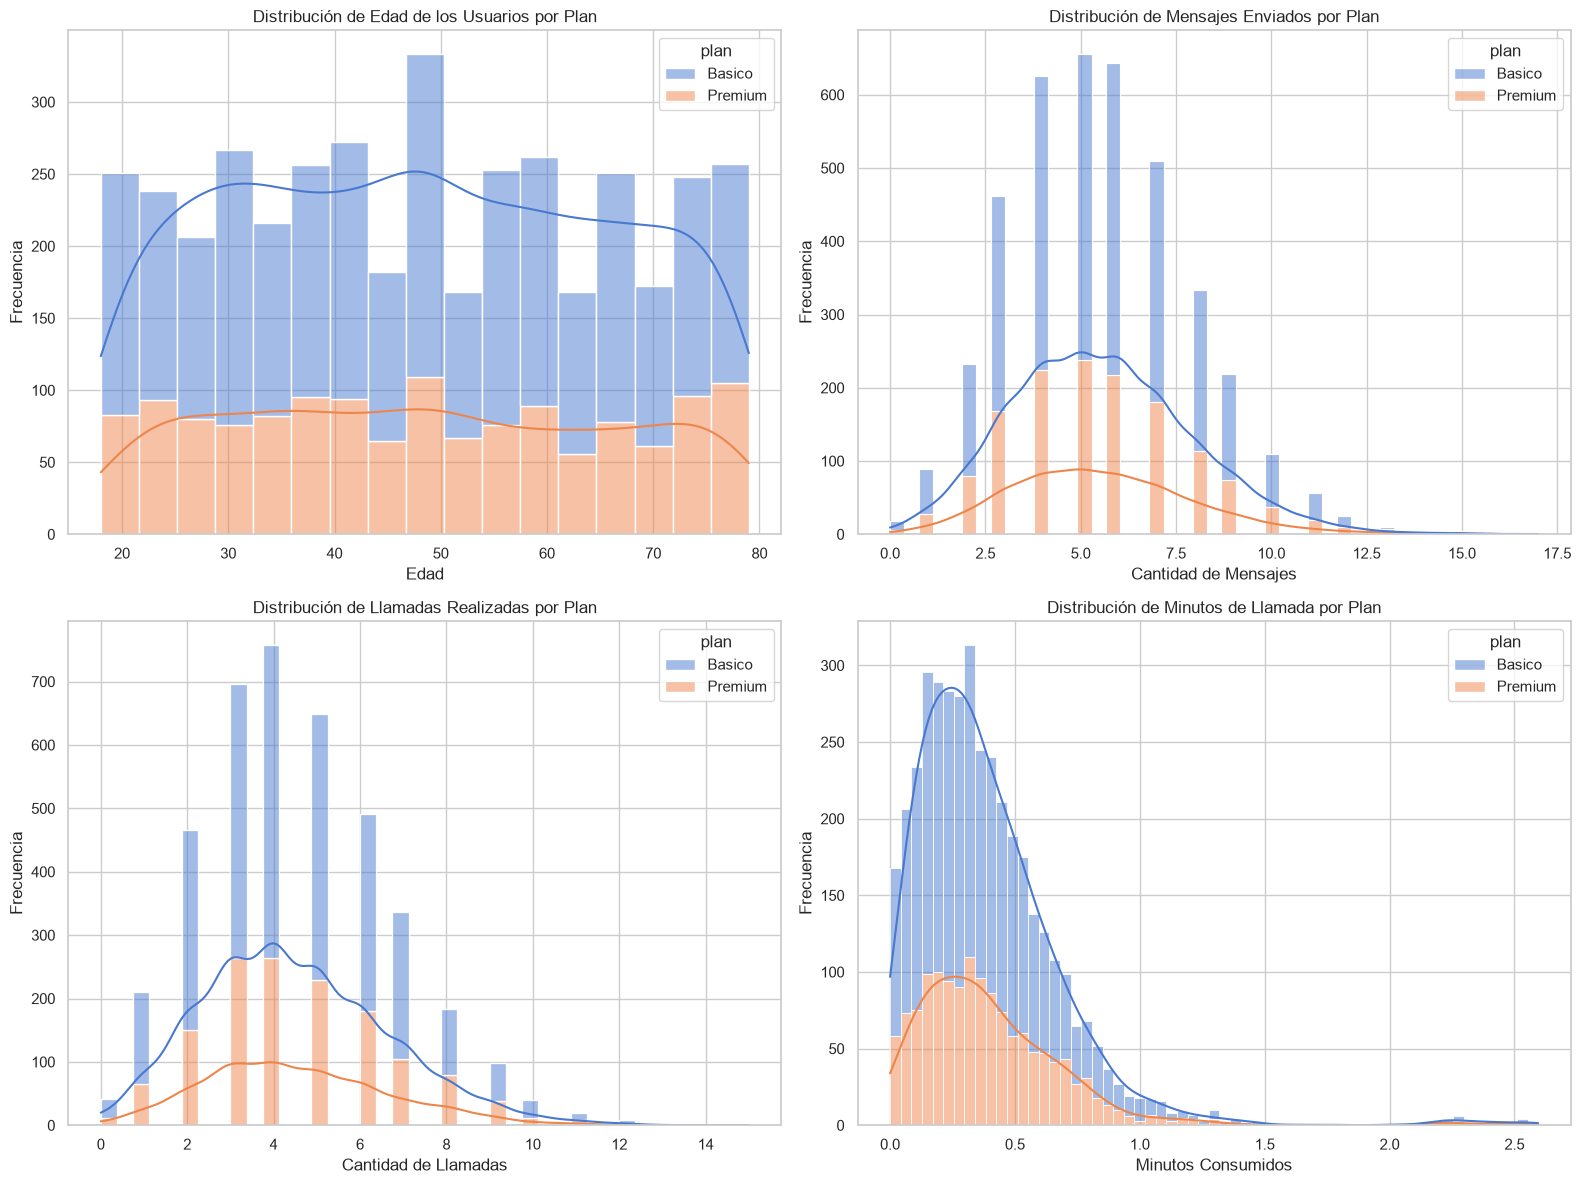

In [18]:
# Configuración estética global para el reporte visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de Edades
sns.histplot(data=user_profile, x="age", hue="plan", kde=True, multiple="stack", ax=axes[0, 0], palette="muted")
axes[0, 0].set_title("Distribución de Edad de los Usuarios por Plan")
axes[0, 0].set_xlabel("Edad")
axes[0, 0].set_ylabel("Frecuencia")

# 2. Distribución de Mensajes Enviados
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", kde=True, multiple="stack", ax=axes[0, 1], palette="muted")
axes[0, 1].set_title("Distribución de Mensajes Enviados por Plan")
axes[0, 1].set_xlabel("Cantidad de Mensajes")
axes[0, 1].set_ylabel("Frecuencia")

# 3. Distribución de Llamadas Realizadas
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", kde=True, multiple="stack", ax=axes[1, 0], palette="muted")
axes[1, 0].set_title("Distribución de Llamadas Realizadas por Plan")
axes[1, 0].set_xlabel("Cantidad de Llamadas")
axes[1, 0].set_ylabel("Frecuencia")

# 4. Distribución de Minutos de Llamada Consumidos
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", kde=True, multiple="stack", ax=axes[1, 1], palette="muted")
axes[1, 1].set_title("Distribución de Minutos de Llamada por Plan")
axes[1, 1].set_xlabel("Minutos Consumidos")
axes[1, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()